# 04. Statistical Hypothesis and Baseline Model

У цьому ноутбуці перевіряю статистичну гіпотезу щодо зв’язку між попередніми відхиленими заявками та дефолтом, а також будую просту baseline-модель для прогнозування дефолту.

Для аналізу використовую підготовлені файли `app_clean.csv` та `prev_clean.csv`, створені в ноутбуці `01_data_preparation.ipynb`.

In [1]:
import pandas as pd
import numpy as np

from statsmodels.stats.proportion import proportions_ztest

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Завантаження підготовлених даних

app_clean = pd.read_csv("../data/processed/app_clean.csv")
prev_clean = pd.read_csv("../data/processed/prev_clean.csv")

print(f"app_clean shape: {app_clean.shape}")
print(f"prev_clean shape: {prev_clean.shape}")

app_clean shape: (307511, 129)
prev_clean shape: (1670214, 37)


## 9. Statistical hypothesis

На цьому етапі перевіряю статистичну гіпотезу про зв’язок між історією попередніх відхилених заявок і поточним ризиком дефолту.

Оскільки в таблиці `previous_application` один клієнт може мати кілька попередніх заявок, спочатку створюю ознаку на рівні клієнта: чи мав клієнт хоча б одну попередню заявку зі статусом `Refused`.

Далі порівнюю `default rate` між двома групами клієнтів:

- клієнти, які мали хоча б одну попередню відхилену заявку;
- клієнти без попередніх відхилених заявок.

Формулювання гіпотез

**H0:** рівень дефолту не відрізняється між клієнтами з попередніми відхиленими заявками та клієнтами без таких заявок.

**H1:** клієнти з попередніми відхиленими заявками мають вищий рівень дефолту.

Рівень значущості: `alpha = 0.05`.

In [3]:
# Створюємо ознаку: чи мав клієнт хоча б одну попередню заявку зі статусом Refused

refused_clients = (
    prev_clean["NAME_CONTRACT_STATUS"]
    .eq("Refused")
    .groupby(prev_clean["SK_ID_CURR"])
    .any()
    .reset_index(name="has_refused_previous_application")
)

hypothesis_df = app_clean[["SK_ID_CURR", "TARGET"]].merge(
    refused_clients,
    on="SK_ID_CURR",
    how="left"
)

hypothesis_df["has_refused_previous_application"] = (
    hypothesis_df["has_refused_previous_application"]
    .fillna(False)
    .astype(bool)
)

hypothesis_df.head()

,SK_ID_CURR,TARGET,has_refused_previous_application
0,100002,1,False
1,100003,0,False
2,100004,0,False
3,100006,0,True
4,100007,0,False


Після створення ознаки `has_refused_previous_application` порівнюю кількість клієнтів, кількість дефолтних клієнтів і `default rate` у двох групах: з попередньо відхиленими заявками та без них.

In [4]:
# Порівняння default rate між клієнтами з попередніми Refused-заявками та без них

hypothesis_summary = (
    hypothesis_df
    .groupby("has_refused_previous_application")
    .agg(
        clients_count=("SK_ID_CURR", "count"),
        default_clients=("TARGET", "sum"),
        default_rate=("TARGET", "mean")
    )
    .reset_index()
)

hypothesis_summary["default_rate"] = (
    hypothesis_summary["default_rate"] * 100
).round(2)

hypothesis_summary

,has_refused_previous_application,clients_count,default_clients,default_rate
0,False,207217,14473,6.98
1,True,100294,10352,10.32


Клієнти, які мали хоча б одну попередню заявку зі статусом `Refused`, мають вищий `default rate` — **10.32%** проти **6.98%** у клієнтів без таких заявок.

Далі потрібно перевірити, чи ця різниця є статистично значущою.

Для статистичної перевірки використовую two-proportion z-test, оскільки порівнюю дві частки: `default rate` у групі клієнтів з попередніми відхиленими заявками та без них.

Тест є одностороннім, оскільки альтернативна гіпотеза передбачає, що клієнти з попередніми відхиленими заявками мають вищий рівень дефолту.

In [5]:
summary_for_test = hypothesis_summary.set_index("has_refused_previous_application")

count = [
    summary_for_test.loc[True, "default_clients"],
    summary_for_test.loc[False, "default_clients"]
]

nobs = [
    summary_for_test.loc[True, "clients_count"],
    summary_for_test.loc[False, "clients_count"]
]

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="larger"
)

print(f"Z-статистика: {z_stat:.4f}")
print(f"P-value: {p_value:.2e}")

Z-статистика: 31.8467
P-value: 7.31e-223


In [6]:
alpha = 0.05

if p_value < alpha:
    print("Відхиляємо H0: клієнти з попередніми відхиленими заявками мають статистично значуще вищий рівень дефолту.")
else:
    print("Не відхиляємо H0: недостатньо доказів, що клієнти з попередніми відхиленими заявками мають вищий рівень дефолту.")

Відхиляємо H0: клієнти з попередніми відхиленими заявками мають статистично значуще вищий рівень дефолту.


**Висновок:**

Результат two-proportion z-test показав, що `p-value` є дуже малим і меншим за `alpha = 0.05`, тому нульову гіпотезу `H0` відхиляємо.

Це означає, що різниця між двома групами є статистично значущою: клієнти, які мали хоча б одну попередню заявку зі статусом `Refused`, мають вищий рівень дефолту.

У вибірці `default rate` для клієнтів з попередніми відхиленими заявками становить **10.32%**, тоді як для клієнтів без таких заявок — **6.98%**.

Отже, наявність попередньо відхилених заявок може бути корисною ознакою для оцінки ризику дефолту.

## 10. Bonus: Simple Default Prediction Model

У цьому блоці будую просту базову модель для прогнозування дефолту клієнта.

Мета блоку — не створити production-ready модель, а показати базовий ML-підхід: вибір ознак, поділ на train/test, масштабування числових змінних, навчання моделі та оцінка якості.

Для моделі використовую Logistic Regression як простий і зрозумілий baseline для задачі класифікації.

### 10.1 Feature selection

Для базової моделі використовую невеликий набір ознак, які були створені або проаналізовані раніше.

Модель використовує:

- `age_years` — вік клієнта;
- `employment_years` — стаж роботи;
- `credit_income_ratio` — співвідношення суми кредиту до доходу;
- `annuity_income_ratio` — співвідношення ануїтетного платежу до доходу;
- `has_refused_previous_application` — чи мав клієнт хоча б одну попередню заявку зі статусом `Refused`.

Цільова змінна — `TARGET`.

На цьому етапі не використовую всі доступні колонки, щоб модель залишалась простою та зрозумілою як baseline.

In [7]:
# Підготовка датасету для базової ML-моделі

model_df = app_clean[
    [
        "SK_ID_CURR",
        "TARGET",
        "age_years",
        "employment_years",
        "credit_income_ratio",
        "annuity_income_ratio"
    ]
].merge(
    hypothesis_df[["SK_ID_CURR", "has_refused_previous_application"]],
    on="SK_ID_CURR",
    how="left"
)

model_df["has_refused_previous_application"] = (
    model_df["has_refused_previous_application"]
    .fillna(False)
    .astype(int)
)

model_df.head()

,SK_ID_CURR,TARGET,age_years,employment_years,credit_income_ratio,annuity_income_ratio,has_refused_previous_application
0,100002,1,25.9,1.7,2.01,0.12,0
1,100003,0,45.9,3.3,4.79,0.13,0
2,100004,0,52.2,0.6,2.00,0.10,0
3,100006,0,52.1,8.3,2.32,0.22,1
4,100007,0,54.6,8.3,4.22,0.18,0


In [8]:
# Перевірка розміру та пропущених значень

print(f"Rows: {model_df.shape[0]}")
print(f"Columns: {model_df.shape[1]}")

model_df.isna().sum()

Rows: 307511
Columns: 7


SK_ID_CURR                              0
TARGET                                  0
age_years                               0
employment_years                    55374
credit_income_ratio                     0
annuity_income_ratio                   12
has_refused_previous_application        0
dtype: int64

У датасет для моделі включено лише базові числові ознаки та одну ознаку з історії попередніх заявок.

Перед навчанням моделі потрібно обробити пропущені значення та розділити дані на train/test.

### 10.2 Train/test split

На цьому етапі розділяю дані на ознаки `X` та цільову змінну `y`.

Щоб уникнути data leakage, спочатку виконую поділ на train/test, а вже після цього буду обробляти пропущені значення та масштабувати ознаки.

In [9]:
# Розділяємо дані на ознаки та цільову змінну

X = model_df.drop(columns=["SK_ID_CURR", "TARGET"])
y = model_df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train default rate: {y_train.mean() * 100:.2f}%")
print(f"y_test default rate: {y_test.mean() * 100:.2f}%")

X_train shape: (246008, 5)
X_test shape: (61503, 5)
y_train default rate: 8.07%
y_test default rate: 8.07%


Дані розділено на train/test у пропорції 80/20.

Параметр `stratify=y` використано через незбалансованість цільової змінної, щоб частка дефолтів у train та test була приблизно однаковою.

### 10.3 Missing values and scaling

Після поділу даних на train/test обробляю пропущені значення та масштабую ознаки.

Щоб уникнути data leakage, `SimpleImputer` та `StandardScaler` навчаються тільки на `X_train`, а до `X_test` застосовується лише `transform`.

In [10]:
# Заповнюємо пропущені значення медіаною

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Масштабуємо ознаки

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (246008, 5)
X_test_scaled shape: (61503, 5)


Пропущені значення заповнено медіаною, оскільки цей підхід є простим і стійкішим до викидів.

Масштабування виконано після train/test split: `fit` застосовано лише до train-даних, а test-дані тільки трансформовано.

### 10.4 Logistic Regression model

На цьому етапі навчаю просту baseline-модель `Logistic Regression`.

Це базова модель для задачі класифікації, яка допоможе перевірити, чи можуть обрані ознаки хоча б частково відрізняти клієнтів із дефолтом від клієнтів без дефолту.

In [11]:
# Навчання baseline-моделі Logistic Regression

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

Модель навчено на масштабованих train-даних. Для оцінки якості збережено як прогноз класу `y_pred`, так і ймовірність дефолту `y_pred_proba`.

### 10.5 Model evaluation

На цьому етапі оцінюю якість baseline-моделі на test-даних.

Оскільки цільова змінна `TARGET` є незбалансованою, важливо дивитися не лише на `accuracy`, а й на `precision`, `recall`, `F1-score` та `ROC-AUC`.

In [12]:
# Оцінка якості моделі

model_metrics = pd.DataFrame({
    "metric": [
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ],
    "value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        roc_auc_score(y_test, y_pred_proba)
    ]
})

model_metrics["value"] = model_metrics["value"].round(4)

model_metrics

,metric,value
0,accuracy,0.9193
1,precision,0.0000
2,recall,0.0000
3,f1_score,0.0000
4,roc_auc,0.6153


In [13]:
# Детальний звіт по класах

print(classification_report(
    y_test,
    y_pred,
    target_names=["No default", "Default"],
    zero_division=0
))

              precision    recall  f1-score   support

  No default       0.92      1.00      0.96     56538
     Default       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



In [14]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual no default", "Actual default"],
    columns=["Predicted no default", "Predicted default"]
)

cm_df

,Predicted no default,Predicted default
Actual no default,56538,0
Actual default,4965,0


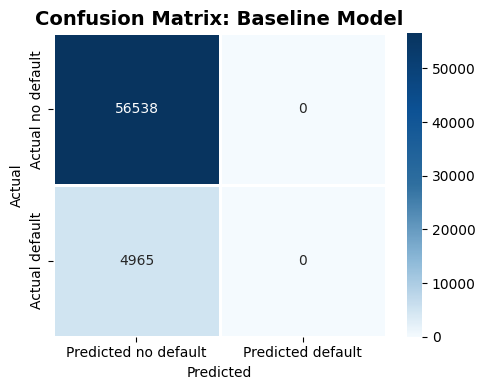

In [15]:
blue_cmap = LinearSegmentedColormap.from_list(
    "project_blue",
    ["#F4FAFE", "#8DB9D8", "#2F6F9F", "#0C5194", "#08345F"]
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=blue_cmap,
    cbar=True,
    linewidths=0.8,
    linecolor="white",
    xticklabels=["Predicted no default", "Predicted default"],
    yticklabels=["Actual no default", "Actual default"]
)

plt.title("Confusion Matrix: Baseline Model", fontsize=14, fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

Baseline-модель переважно прогнозує клас більшості — “No default”. Це підтверджує, що перед реальним використанням моделі для виявлення дефолтів потрібно працювати з дисбалансом класів.

**Висновок:**

Baseline-модель `Logistic Regression` показала високу `accuracy` — **91.93%**, але цей показник є оманливим через сильну незбалансованість цільової змінної.

За `confusion matrix` видно, що модель прогнозує всі спостереження як `No default` і не визначає жодного клієнта з дефолтом. Через це `precision`, `recall` та `F1-score` для класу `Default` дорівнюють **0**.

`ROC-AUC` становить **0.6153**, тобто модель має слабку здатність розділяти клієнтів із дефолтом та без дефолту, але результат трохи кращий за випадкове вгадування.

Цей блок є базовим ML-прикладом, а не фінальною production-ready моделлю. Для покращення результату в майбутньому потрібно додати більше ознак, працювати з дисбалансом класів і тестувати інші моделі або пороги класифікації.

## Summary

У цьому ноутбуці перевірено статистичну гіпотезу про зв’язок між попередніми відхиленими заявками та поточним ризиком дефолту.

Результат two-proportion z-test показав, що клієнти з попередніми заявками зі статусом `Refused` мають статистично значуще вищий рівень дефолту.

Також було побудовано просту baseline-модель `Logistic Regression`. Модель показала високу `accuracy`, але через незбалансованість цільової змінної не змогла коректно визначити клієнтів з дефолтом.

Цей результат показує, що для подальшого покращення моделі потрібно працювати з дисбалансом класів, додавати більше ознак і тестувати інші підходи.